### Step 1 — Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2 — Load Dataset

In [10]:
df = pd.read_csv("/Users/siddharthkushwaha/Desktop/Cognifyz/Level_1_Task3/cleaned_zomato_dataset.csv")

In [11]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


### Step 3 — Check Latitude and Longitude

In [12]:
print(df[["Latitude", "Longitude"]].head())

    Latitude   Longitude
0  14.565443  121.027535
1  14.553708  121.014101
2  14.581404  121.056831
3  14.585318  121.056475
4  14.584450  121.057508


### Missing values:

In [13]:
print(df[["Latitude", "Longitude"]].isnull().sum())

Latitude     0
Longitude    0
dtype: int64


### Step 4 — Plot Restaurant Locations

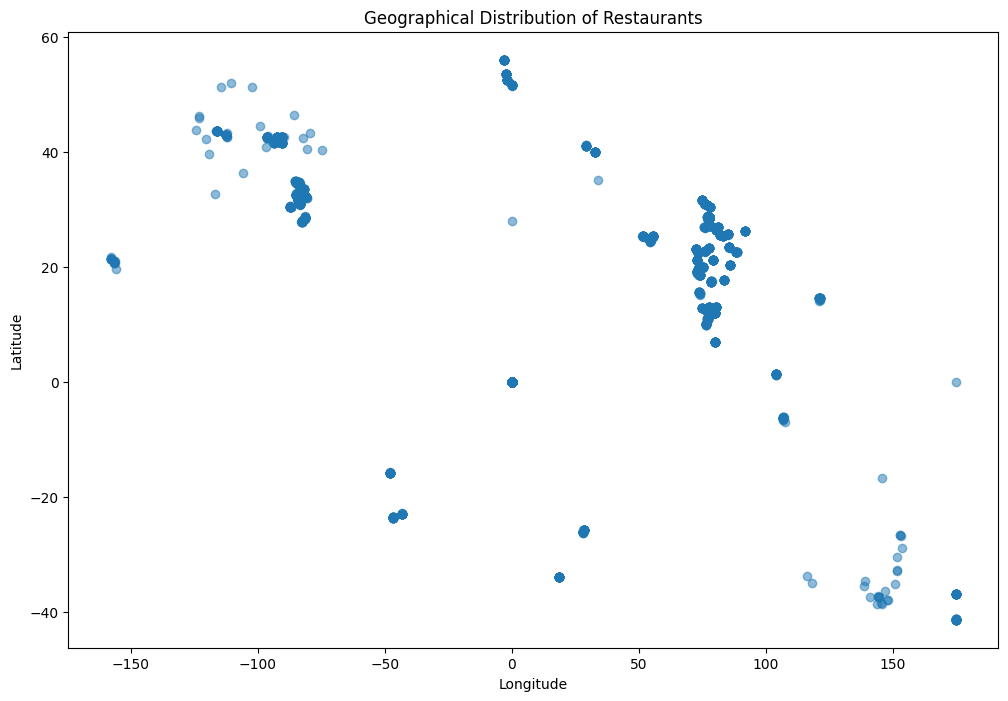

In [14]:
plt.figure(figsize=(12, 8))

plt.scatter(df["Longitude"],df["Latitude"],alpha=0.5)

plt.title("Geographical Distribution of Restaurants")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

### Step 5 — Location According to Rating

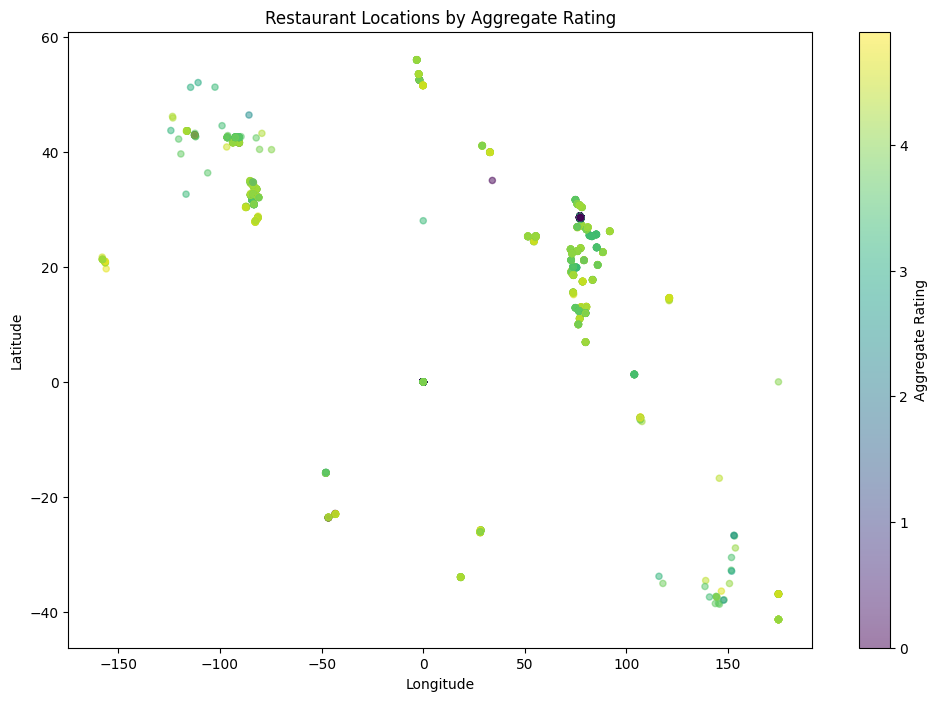

In [15]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(df["Longitude"],df["Latitude"],c=df["Aggregate rating"],s=20,alpha=0.5,cmap="viridis")

plt.colorbar(scatter, label="Aggregate Rating")

plt.title("Restaurant Locations by Aggregate Rating")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

### Step 6 — Top Cities by Number of Restaurants

In [16]:
city_counts = df["City"].value_counts()

print(city_counts.head(10))

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Amritsar          21
Ahmedabad         21
Lucknow           21
Guwahati          21
Name: count, dtype: int64


Visualization:

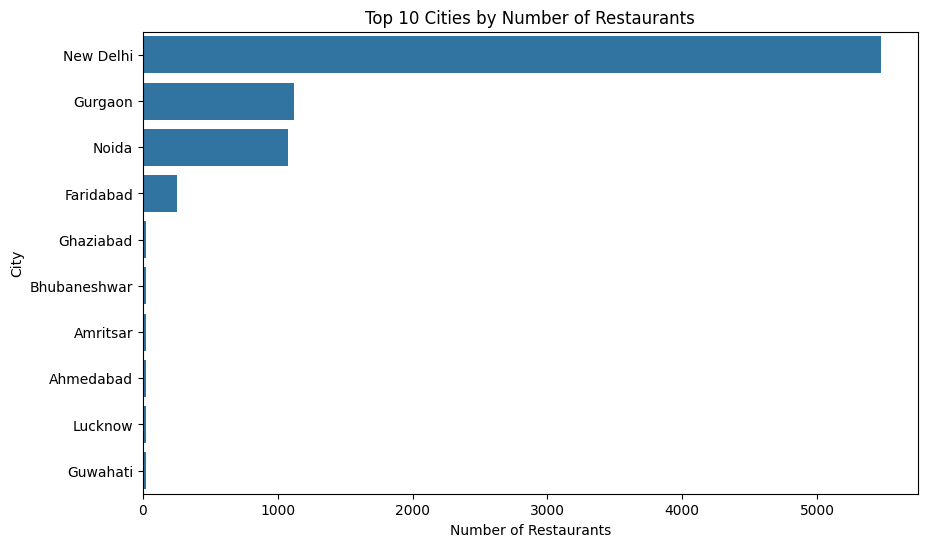

In [17]:
top_cities = city_counts.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(x=top_cities.values,y=top_cities.index)

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")

plt.show()

### Step 7 — Country-wise Distribution

In [18]:
country_counts = df["Country Code"].value_counts()

print(country_counts)

Country Code
1      8652
216     434
215      80
30       60
214      60
189      60
148      40
208      34
14       24
162      22
94       21
184      20
166      20
191      20
37        4
Name: count, dtype: int64


Visualization:

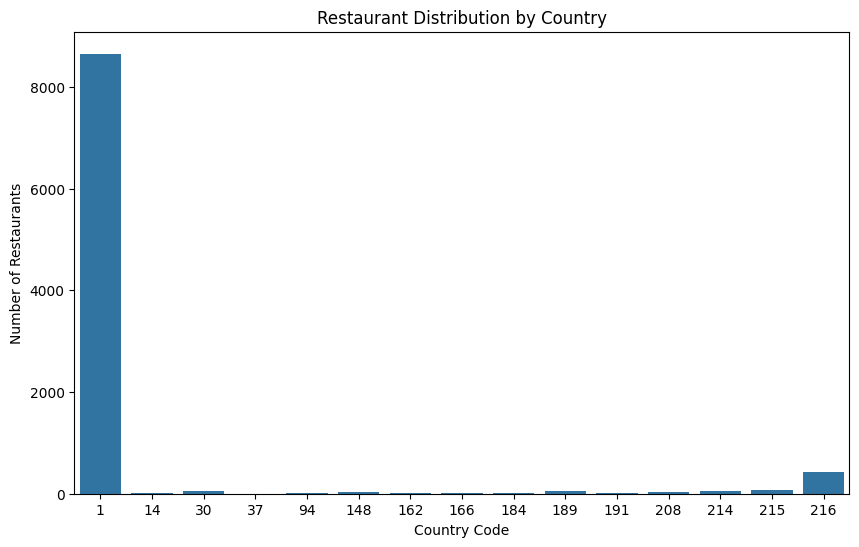

In [19]:
plt.figure(figsize=(10, 6))

sns.barplot(x=country_counts.index,y=country_counts.values)

plt.title("Restaurant Distribution by Country")
plt.xlabel("Country Code")
plt.ylabel("Number of Restaurants")

plt.show()

### Step 8 — Average Rating by City

In [20]:
city_rating = (df.groupby("City")["Aggregate rating"].mean().sort_values(ascending=False))

print(city_rating.head(10))

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Tagaytay City       4.500000
Secunderabad        4.500000
Name: Aggregate rating, dtype: float64


Top 10 cities:

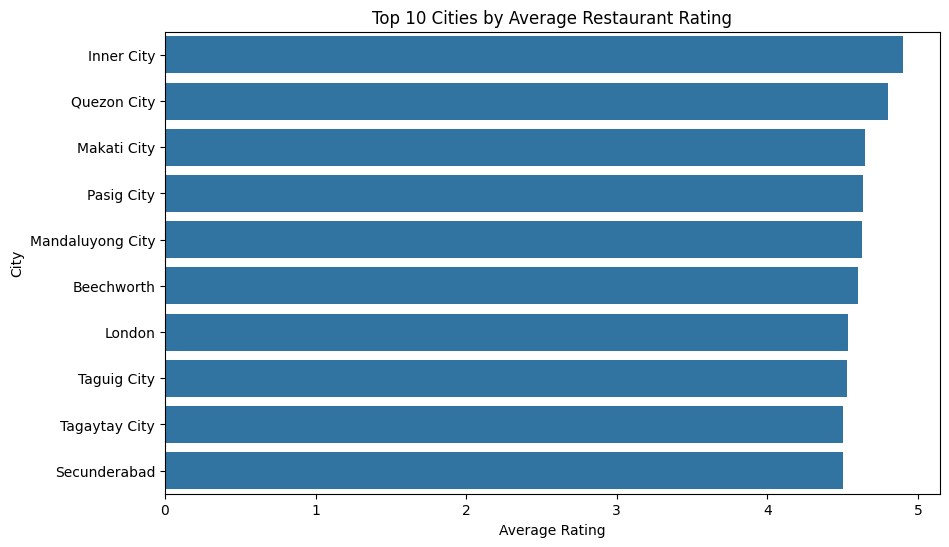

In [21]:
top_city_rating = city_rating.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(x=top_city_rating.values,y=top_city_rating.index)

plt.title("Top 10 Cities by Average Restaurant Rating")
plt.xlabel("Average Rating")
plt.ylabel("City")

plt.show()